In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import random
from sklearn.metrics import confusion_matrix


# A


In [25]:
df = pd.read_csv('/content/hotel_bookings.csv')

In [26]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,12:16:41 AM,Chandigarh
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,12:56:22 AM,Mumbai
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,12:46:26 AM,Delhi
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,12:07:10 AM,Kolkata
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,12:27:33 AM,Lucknow


In [27]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
119385,City Hotel - Pune,0,23,2024,September,39,29,2,5,2,...,394.0,NaN,0,Transient,96.14,0,0,Check-Out,12:33:06 AM,Pune
119386,City Hotel - Mumbai,0,102,2024,November,46,16,2,5,3,...,9.0,NaN,0,Transient,225.43,0,2,Check-Out,12:55:18 AM,Mumbai
119387,City Hotel - Lucknow,0,34,2024,April,16,19,2,5,2,...,9.0,NaN,0,Transient,157.71,0,4,Check-Out,12:50:23 AM,Lucknow
119388,City Hotel - Ahmedabad,0,109,2024,October,40,5,2,5,2,...,89.0,NaN,0,Transient,104.40,0,0,Check-Out,12:37:40 AM,Ahmedabad
119389,City Hotel - Bhopal,0,205,2024,December,51,21,2,7,2,...,9.0,NaN,0,Transient,151.20,0,2,Check-Out,12:11:08 AM,Bhopal


In [28]:
df.shape

(119390, 33)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [30]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [31]:
(df.isnull().sum()/df.shape[0])*100

,0
hotel,0.000000
is_canceled,0.000000
lead_time,0.000000
arrival_date_year,0.000000
arrival_date_month,0.000000
arrival_date_week_number,0.000000
arrival_date_day_of_month,0.000000
stays_in_weekend_nights,0.000000
stays_in_week_nights,0.000000
adults,0.000000


In [32]:
unique_counts = df.nunique()
print(unique_counts)

hotel                               30
is_canceled                          2
lead_time                          479
arrival_date_year                    1
arrival_date_month                  12
arrival_date_week_number            52
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
meal                                 5
country                            177
market_segment                       8
distribution_channel                 5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
reserved_room_type                  10
assigned_room_type                  12
booking_changes                     21
deposit_type                         3
agent                              333
company                            352
days_in_waiting_list     

In [33]:
cols_to_drop = [
    'reservation_status',
    'reservation_status_date',
    'company',
    'arrival_date_year',
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
]

df.drop(columns=cols_to_drop, inplace=True)

In [34]:
df['agent'] = df['agent'].fillna(0)
print("Imputed missing 'agent' values with 0.")

mode_country = df['country'].mode()[0]
df['country'] = df['country'].fillna(mode_country)
print(f"Imputed missing 'country' values with mode: {mode_country}.")

df['children'] = df['children'].fillna(0)
print("Imputed missing 'children' values with 0.")

df = df.dropna()
print("Dropped remaining rows with any missing values.")

Imputed missing 'agent' values with 0.
Imputed missing 'country' values with mode: PRT.
Imputed missing 'children' values with 0.
Dropped remaining rows with any missing values.


In [35]:
columns_to_int_further = [ 'booking_changes', 'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests']
for col in columns_to_int_further:
    df[col] = df[col].astype(int)
print("Converted additional float columns to integer type.")

print('\nDataFrame Info after further type conversions:')
df.info()

Converted additional float columns to integer type.

DataFrame Info after further type conversions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   hotel                        119390 non-null  object 
 1   is_canceled                  119390 non-null  int64  
 2   lead_time                    119390 non-null  int64  
 3   arrival_date_month           119390 non-null  object 
 4   arrival_date_week_number     119390 non-null  int64  
 5   arrival_date_day_of_month    119390 non-null  int64  
 6   stays_in_weekend_nights      119390 non-null  int64  
 7   stays_in_week_nights         119390 non-null  int64  
 8   adults                       119390 non-null  int64  
 9   children                     119390 non-null  float64
 10  babies                       119390 non-null  int64  
 11  meal             

In [36]:
print(f"Initial number of duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print("Duplicate rows removed.")
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

Initial number of duplicate rows: 66
Duplicate rows removed.
Number of duplicate rows after removal: 0


In [23]:
s = df.select_dtypes(include ="number").corr()
s

,is_canceled,lead_time,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.000000,0.293010,0.000354,-0.003716,-0.001677,0.024952,0.060210,0.005163,-0.032465,-0.144258,-0.046447,0.054179,0.047581,-0.195459,-0.234381
lead_time,0.293010,1.000000,0.004110,-0.000155,0.085907,0.165982,0.119568,-0.037525,-0.020892,0.000194,-0.012486,0.170190,-0.063039,-0.116407,-0.095548
arrival_date_week_number,0.000354,0.004110,1.000000,0.071790,-0.002994,-0.002106,0.001416,0.003551,0.003902,0.002174,-0.001732,0.007390,0.000828,-0.004533,-0.001368
arrival_date_day_of_month,-0.003716,-0.000155,0.071790,1.000000,0.001185,0.001906,-0.000861,-0.000249,-0.003364,0.001466,-0.000849,-0.004733,-0.001440,-0.004204,0.007717
stays_in_weekend_nights,-0.001677,0.085907,-0.002994,0.001185,1.000000,0.499074,0.091809,0.045752,0.018470,0.063254,0.161465,-0.054164,0.049309,-0.018607,0.072624
stays_in_week_nights,0.024952,0.165982,-0.002106,0.001906,0.499074,1.000000,0.092884,0.044163,0.020179,0.096184,0.195135,-0.002026,0.065191,-0.024907,0.068101
adults,0.060210,0.119568,0.001416,-0.000861,0.091809,0.092884,1.000000,0.030393,0.018133,-0.051702,0.025045,-0.008281,0.230763,0.014735,0.122796
children,0.005163,-0.037525,0.003551,-0.000249,0.045752,0.044163,0.030393,1.000000,0.024019,0.048917,0.050591,-0.033263,0.324890,0.056220,0.081669
babies,-0.032465,-0.020892,0.003902,-0.003364,0.018470,0.020179,0.018133,0.024019,1.000000,0.083433,0.030272,-0.010618,0.029185,0.037373,0.097879
booking_changes,-0.144258,0.000194,0.002174,0.001466,0.063254,0.096184,-0.051702,0.048917,0.083433,1.000000,0.036474,-0.011614,0.019617,0.065588,0.052735


<Axes: >

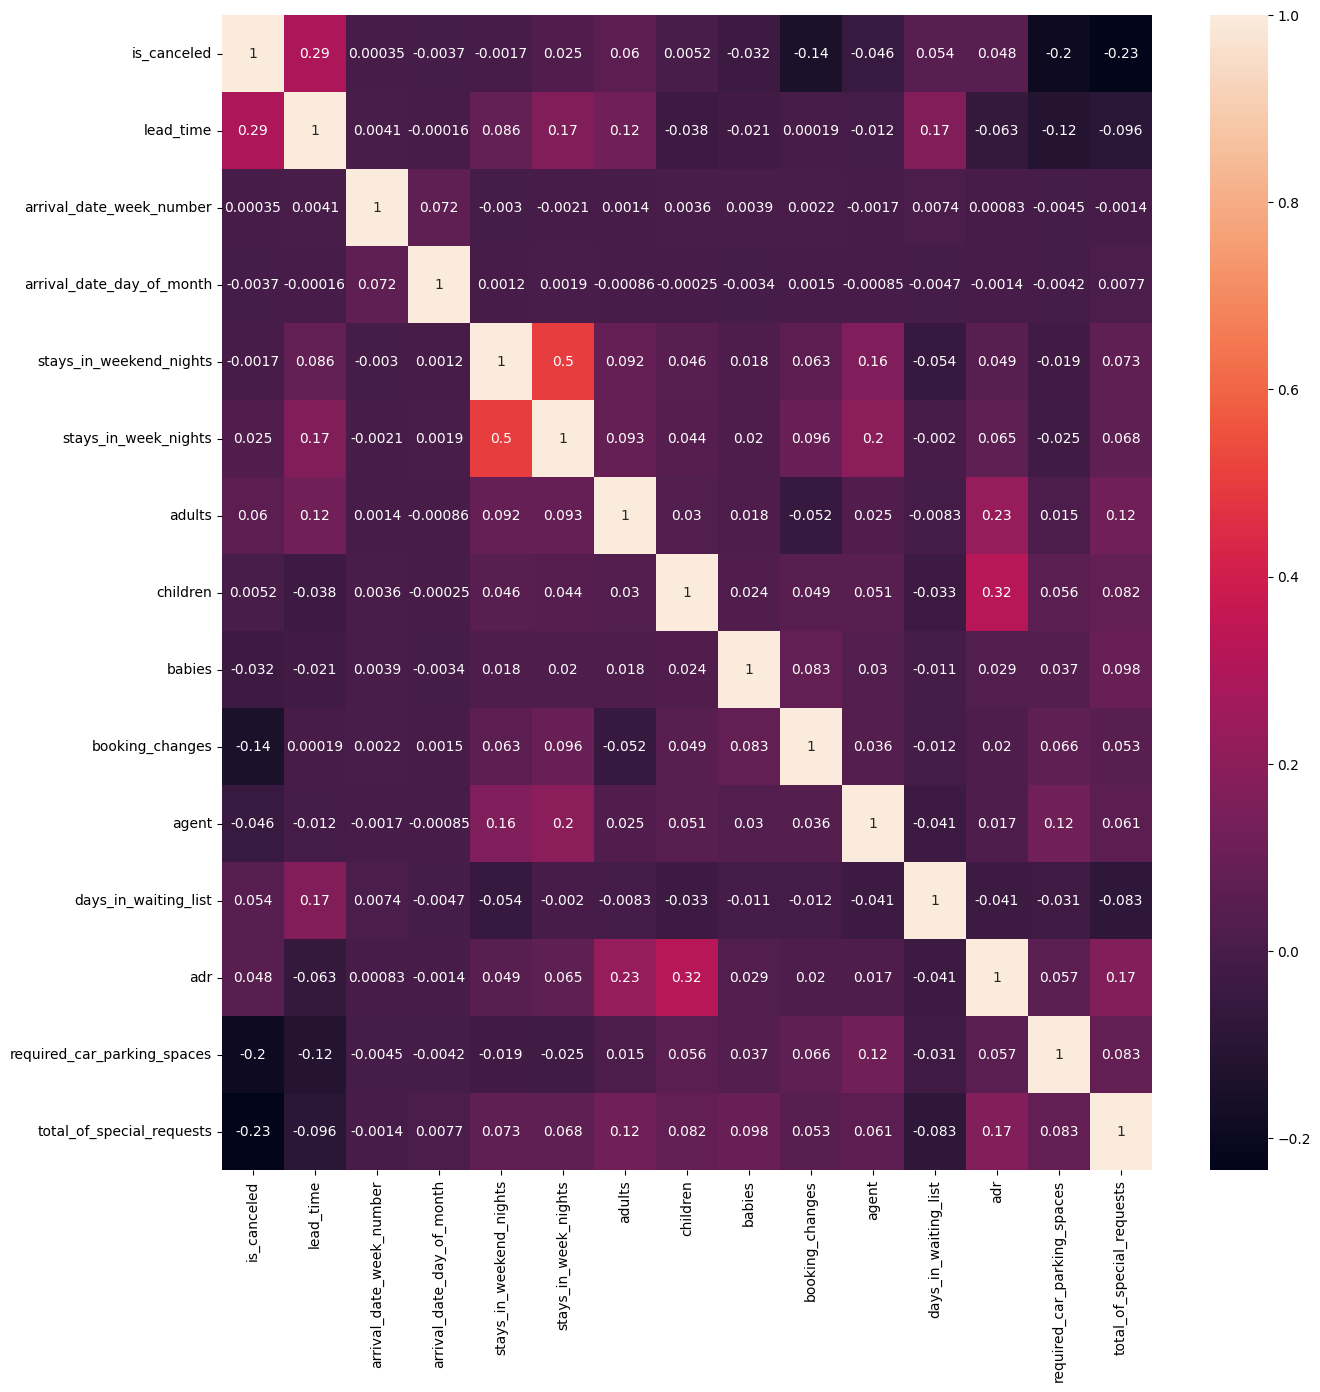

In [37]:
plt.figure(figsize=(15,15))
sns.heatmap(s,annot = True)

In [38]:
def wisker(col):
  q1,q3 = np.percentile(col,[15,85])
  iqr = q3-q1
  lw= q1- 1.5*iqr
  uw = q3 + 1.5*iqr
  return lw,uw

In [39]:
wisker(df['lead_time'])

(np.float64(-307.5), np.float64(528.5))

In [40]:
for i in ["lead_time", "adults", "stays_in_week_nights",
                         "days_in_waiting_list","booking_changes","adr","children"]:
  lw,uw = wisker(df[i])
  df[i]= np.where(df[i] < lw,lw,df[i])
  df[i]= np.where(df[i] > uw,uw,df[i])

In [41]:
df.describe()

,is_canceled,lead_time,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119324.000000,119324.000000,119324.000000,119324.000000,119324.000000,119324.000000,119324.000000,119324.0,119324.000000,119324.000000,119324.000000,119324.0,119324.000000,119324.000000,119324.000000
mean,0.370185,103.807713,26.374401,15.724372,0.927793,2.460490,1.853424,0.0,0.007953,0.203086,74.830193,0.0,101.642899,0.062552,0.571612
std,0.482856,106.144268,15.022226,8.805056,0.998704,1.686915,0.488110,0.0,0.097463,0.524351,107.143396,0.0,47.522811,0.245355,0.792889
min,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,13.000000,8.000000,0.000000,1.000000,2.000000,0.0,0.000000,0.000000,7.000000,0.0,69.290000,0.000000,0.000000
50%,0.000000,69.000000,26.000000,16.000000,1.000000,2.000000,2.000000,0.0,0.000000,0.000000,9.000000,0.0,94.600000,0.000000,0.000000
75%,1.000000,160.000000,39.000000,23.000000,2.000000,3.000000,2.000000,0.0,0.000000,0.000000,152.000000,0.0,126.000000,0.000000,1.000000
max,1.000000,528.500000,52.000000,31.000000,19.000000,8.500000,3.500000,0.0,10.000000,2.500000,535.000000,0.0,277.500000,8.000000,5.000000


In [42]:
df.describe(include = "object")

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,city
count,119324,119324,119324,119324,119324,119324,119324,119324,119324,119324,119324
unique,30,12,5,177,8,5,10,12,3,4,15
top,City Hotel - Ahmedabad,October,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Bhopal
freq,5397,10347,92257,49020,56476,97811,85928,73987,104620,89569,8100


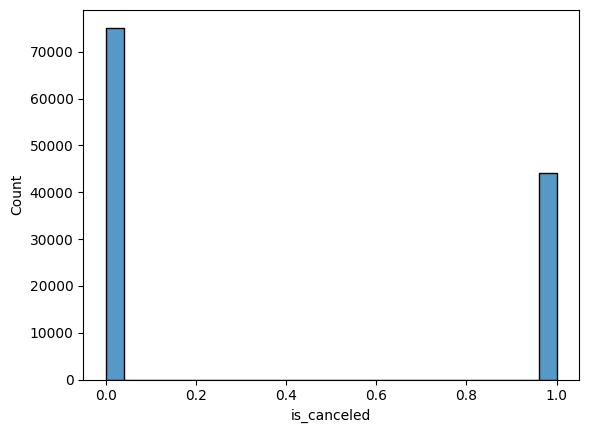

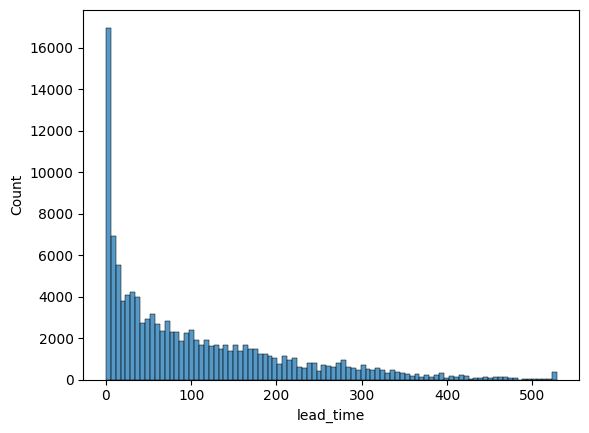

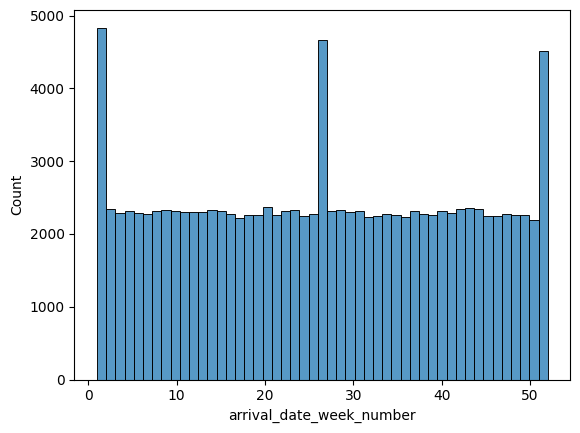

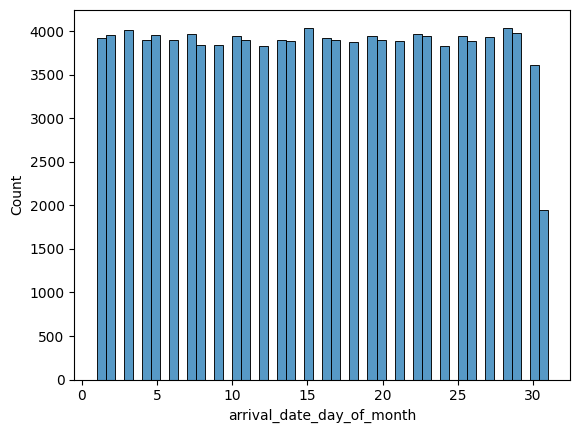

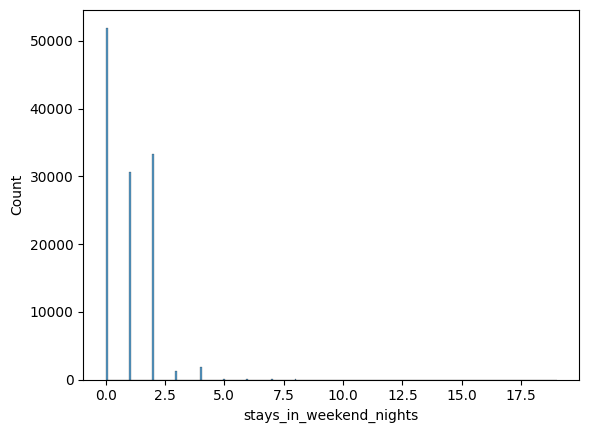

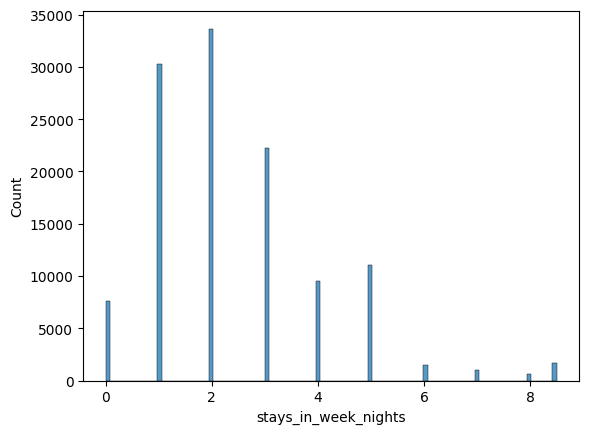

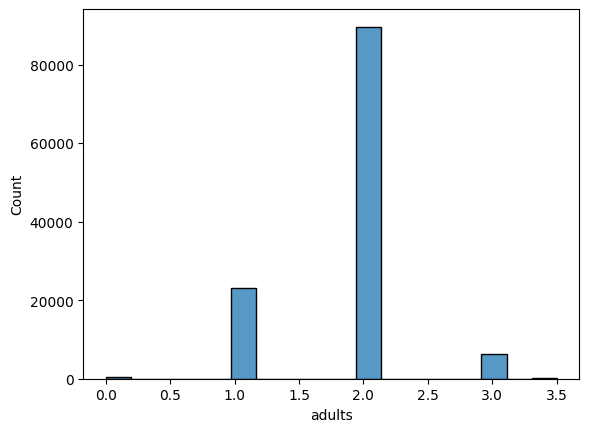

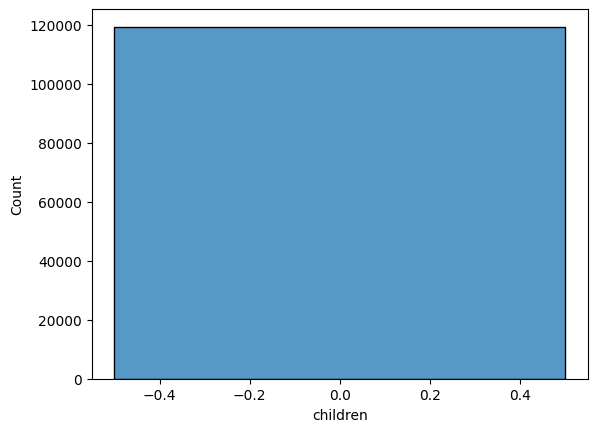

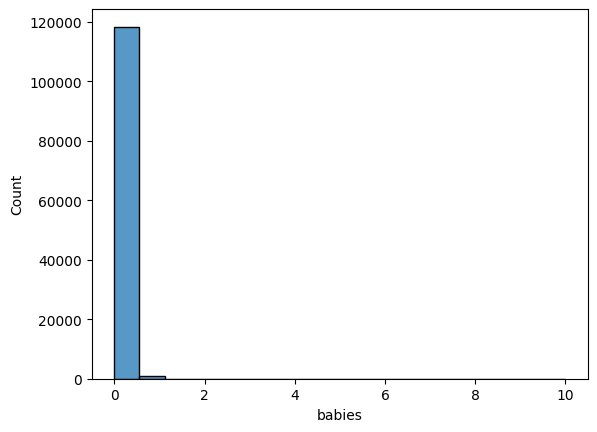

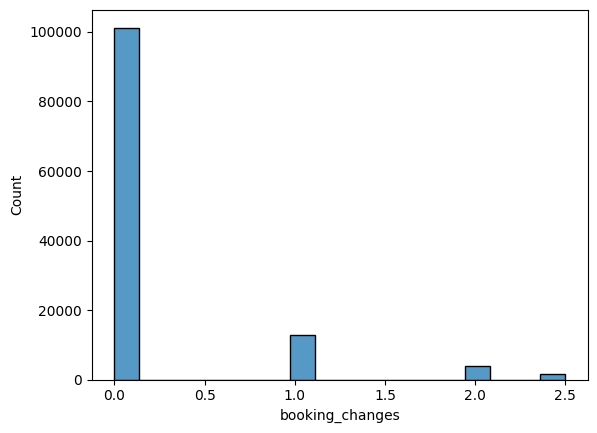

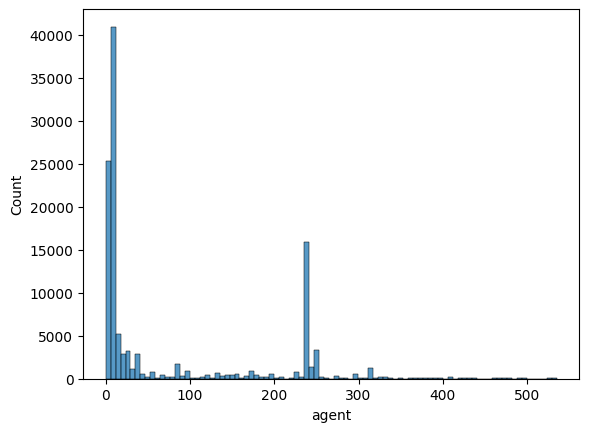

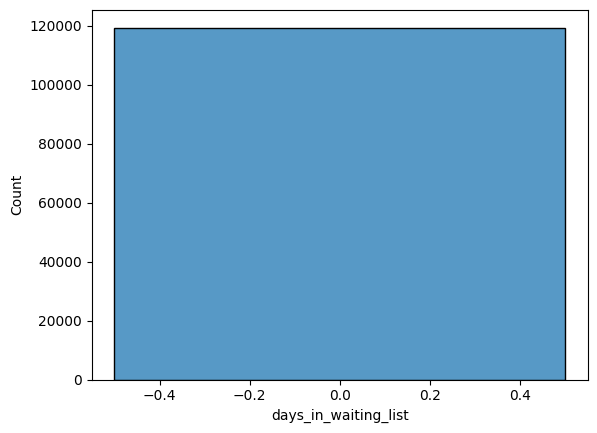

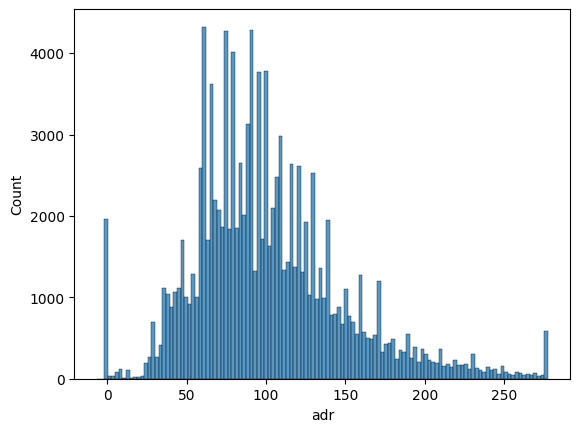

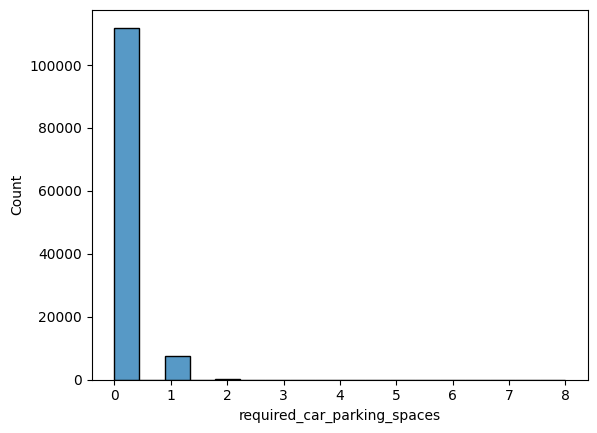

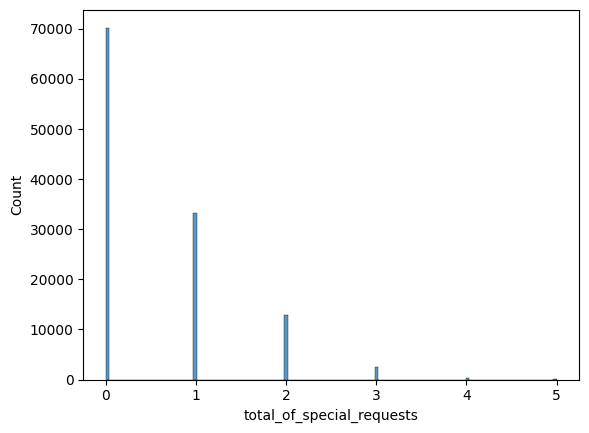

In [43]:
for i in df.select_dtypes(include= "number").columns:
  sns.histplot(data=df,x=i)
  plt.show()

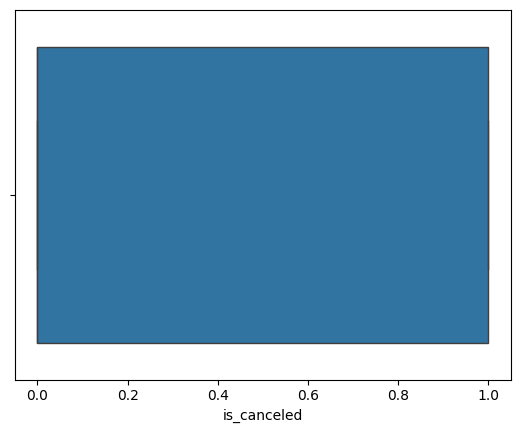

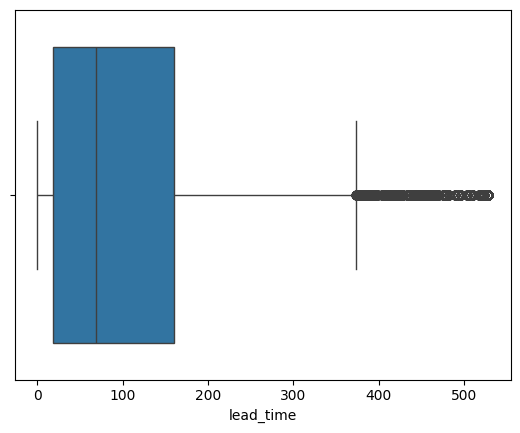

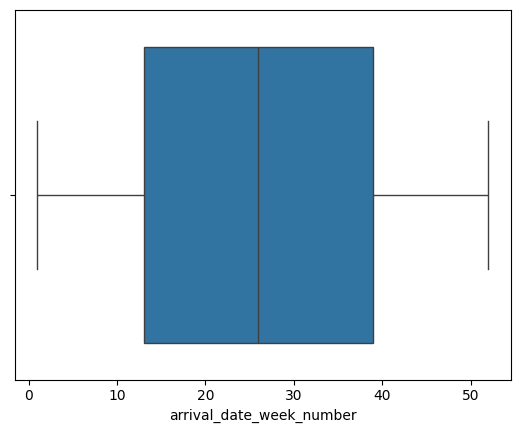

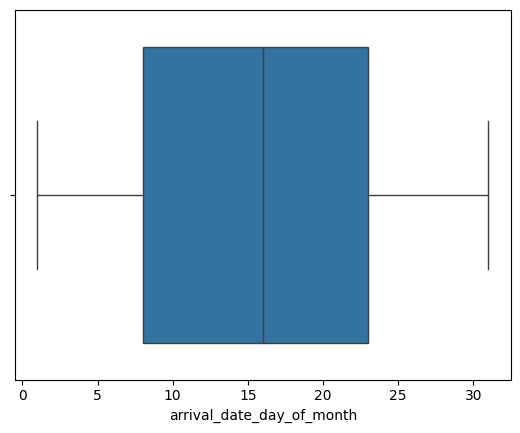

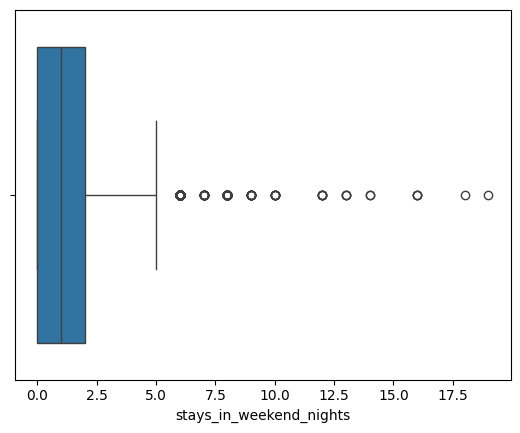

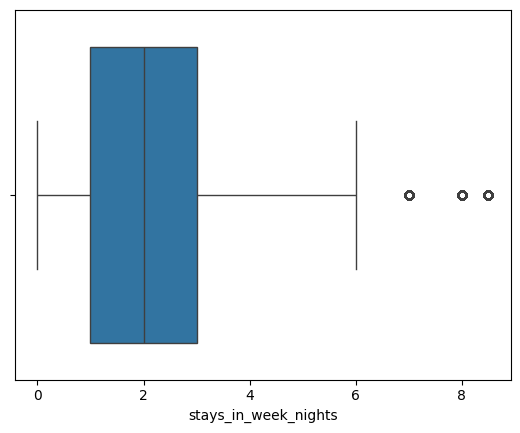

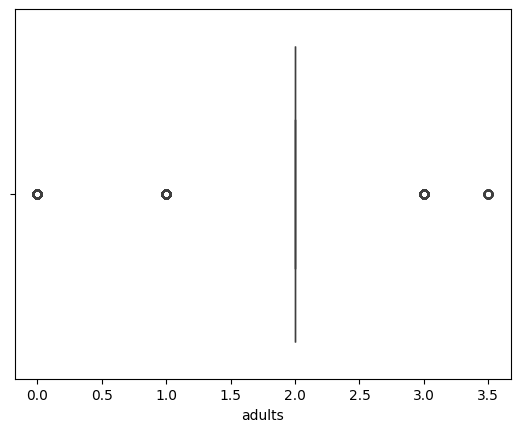

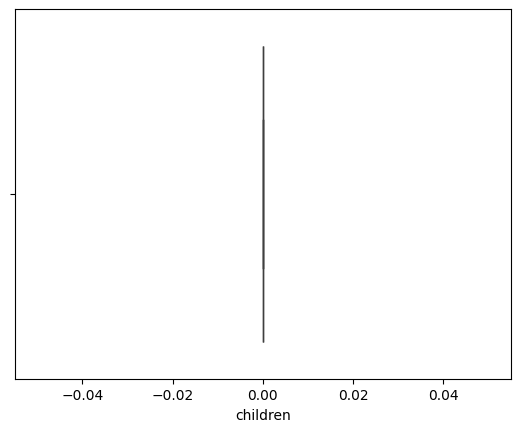

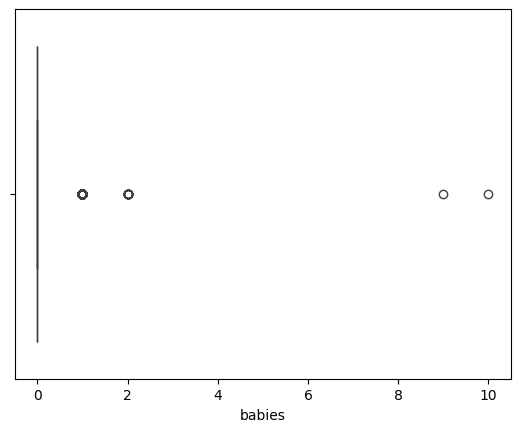

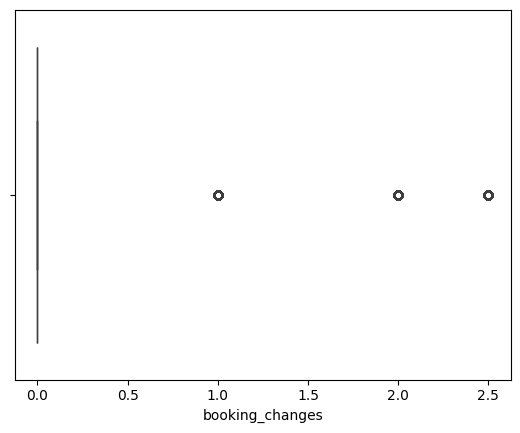

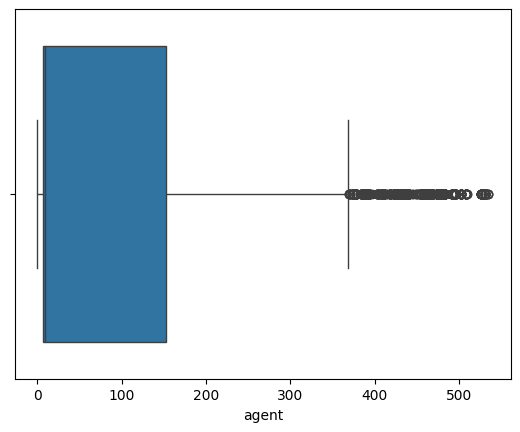

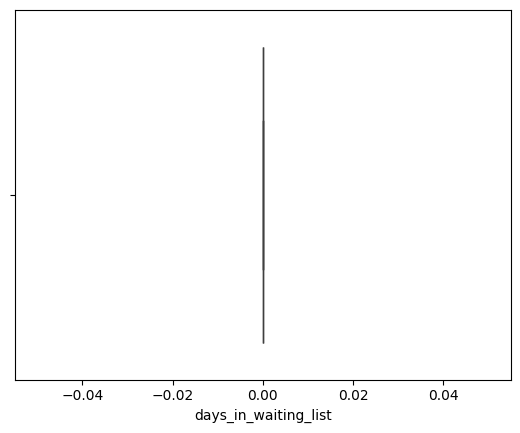

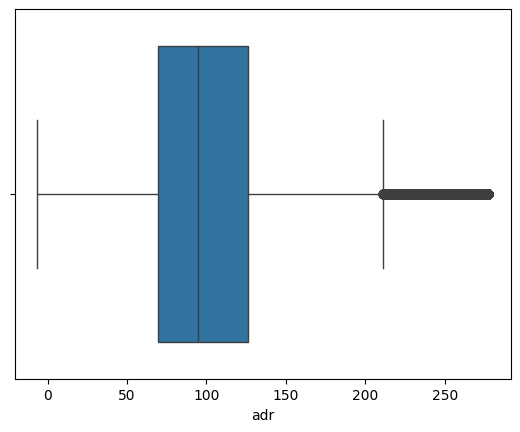

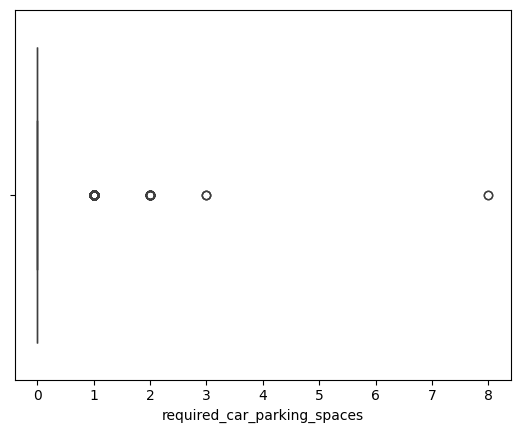

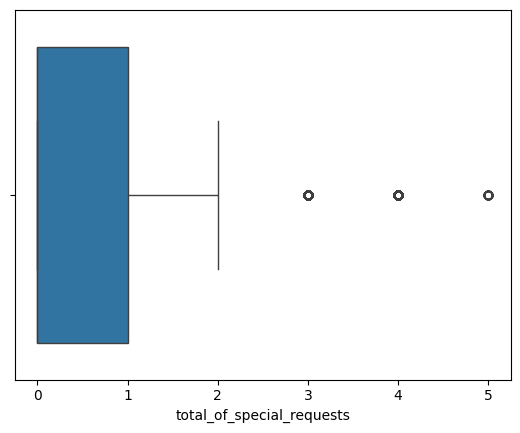

In [44]:
for i in df.select_dtypes(include= "number").columns:
  sns.boxplot(data=df,x=i)
  plt.show()

In [45]:
print(f"DataFrame shape before one-hot encoding: {df.shape}")

categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns identified: {list(categorical_cols)}")

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"DataFrame shape after one-hot encoding: {df_encoded.shape}")

df = df_encoded

print('\nDataFrame Info after categorical to numerical conversion:')
df.info()

DataFrame shape before one-hot encoding: (119324, 26)
Categorical columns identified: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'city']
DataFrame shape after one-hot encoding: (119324, 285)

DataFrame Info after categorical to numerical conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 119324 entries, 0 to 119389
Columns: 285 entries, is_canceled to city_Pune
dtypes: bool(270), float64(8), int64(7)
memory usage: 45.3 MB


In [46]:
print('--- Final DataFrame Info ---')
df.info()
print('\n--- Final DataFrame Descriptive Statistics ---')
df.describe()

--- Final DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 119324 entries, 0 to 119389
Columns: 285 entries, is_canceled to city_Pune
dtypes: bool(270), float64(8), int64(7)
memory usage: 45.3 MB

--- Final DataFrame Descriptive Statistics ---


,is_canceled,lead_time,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119324.000000,119324.000000,119324.000000,119324.000000,119324.000000,119324.000000,119324.000000,119324.0,119324.000000,119324.000000,119324.000000,119324.0,119324.000000,119324.000000,119324.000000
mean,0.370185,103.807713,26.374401,15.724372,0.927793,2.460490,1.853424,0.0,0.007953,0.203086,74.830193,0.0,101.642899,0.062552,0.571612
std,0.482856,106.144268,15.022226,8.805056,0.998704,1.686915,0.488110,0.0,0.097463,0.524351,107.143396,0.0,47.522811,0.245355,0.792889
min,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,13.000000,8.000000,0.000000,1.000000,2.000000,0.0,0.000000,0.000000,7.000000,0.0,69.290000,0.000000,0.000000
50%,0.000000,69.000000,26.000000,16.000000,1.000000,2.000000,2.000000,0.0,0.000000,0.000000,9.000000,0.0,94.600000,0.000000,0.000000
75%,1.000000,160.000000,39.000000,23.000000,2.000000,3.000000,2.000000,0.0,0.000000,0.000000,152.000000,0.0,126.000000,0.000000,1.000000
max,1.000000,528.500000,52.000000,31.000000,19.000000,8.500000,3.500000,0.0,10.000000,2.500000,535.000000,0.0,277.500000,8.000000,5.000000


# #B

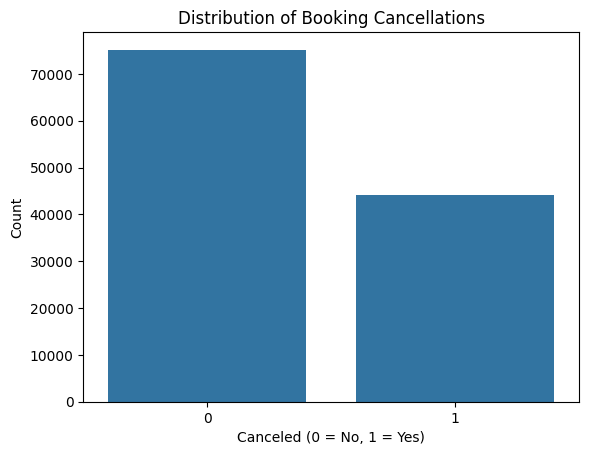

In [47]:
sns.countplot(x='is_canceled', data=df)
plt.title('Distribution of Booking Cancellations')
plt.xlabel('Canceled (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [48]:
month_cols = [col for col in df.columns if col.startswith('arrival_date_month_')]
bookings_per_month = pd.Series()

for col in month_cols:
    month_name = col.replace('arrival_date_month_', '')
    bookings_per_month[month_name] = df[col].sum()

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
bookings_per_month = bookings_per_month.reindex(month_order)

print("Bookings per month (ordered):")
print(bookings_per_month)

Bookings per month (ordered):
January      10120.0
February      9551.0
March        10212.0
April            NaN
May          10205.0
June          9804.0
July         10288.0
August       10026.0
September     9752.0
October      10347.0
November      9686.0
December      9578.0
dtype: float64


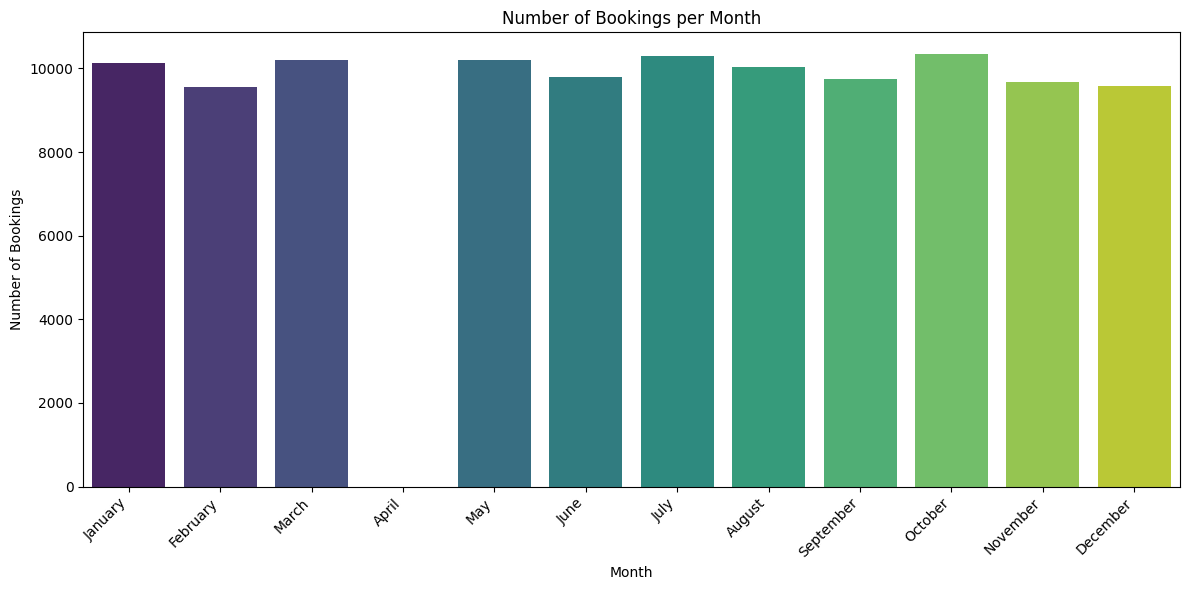

In [49]:
bookings_per_month = bookings_per_month.fillna(0)

plt.figure(figsize=(12, 6))
sns.barplot(x=bookings_per_month.index, y=bookings_per_month.values, hue=bookings_per_month.index, palette='viridis', legend=False)
plt.title('Number of Bookings per Month')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

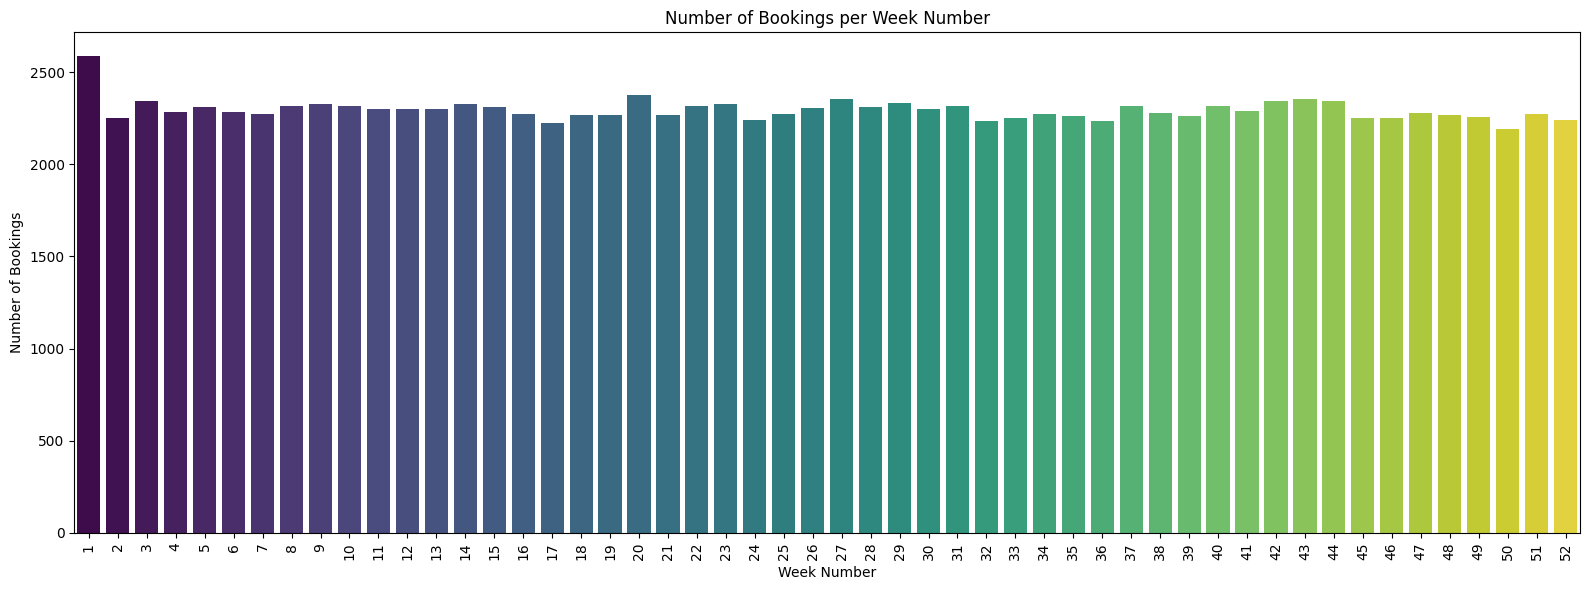

In [50]:
bookings_per_week = df['arrival_date_week_number'].value_counts().sort_index()

plt.figure(figsize=(16, 6))
sns.barplot(x=bookings_per_week.index, y=bookings_per_week.values, palette='viridis', hue=bookings_per_week.index, legend=False)
plt.title('Number of Bookings per Week Number')
plt.xlabel('Week Number')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=90, ha='center')
plt.tight_layout()
plt.show()

In [51]:
city_cols = [col for col in df.columns if col.startswith('city_')]
bookings_per_city = pd.Series()

for col in city_cols:
    city_name = col.replace('city_', '')
    bookings_per_city[city_name] = df[col].sum()

print("Bookings per city:")
print(bookings_per_city.head())

Bookings per city:
Bangalore     7892
Bhopal        8100
Chandigarh    7973
Chennai       7920
Delhi         7972
dtype: int64


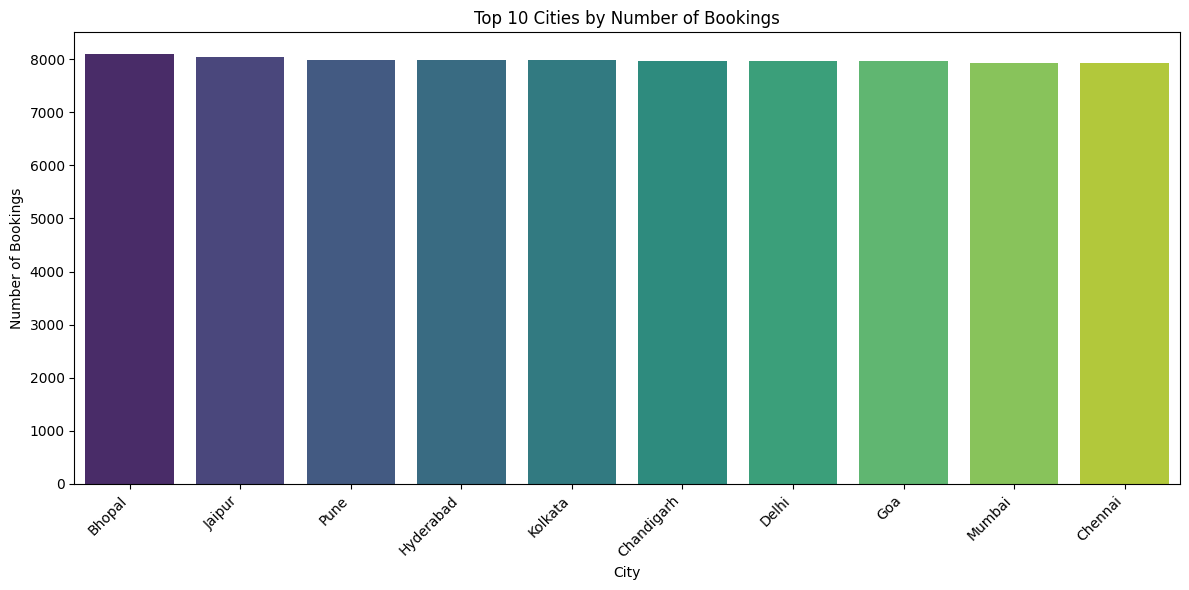

In [52]:
top_10_cities = bookings_per_city.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_cities.index, y=top_10_cities.values, palette='viridis', hue=top_10_cities.index, legend=False)
plt.title('Top 10 Cities by Number of Bookings')
plt.xlabel('City')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

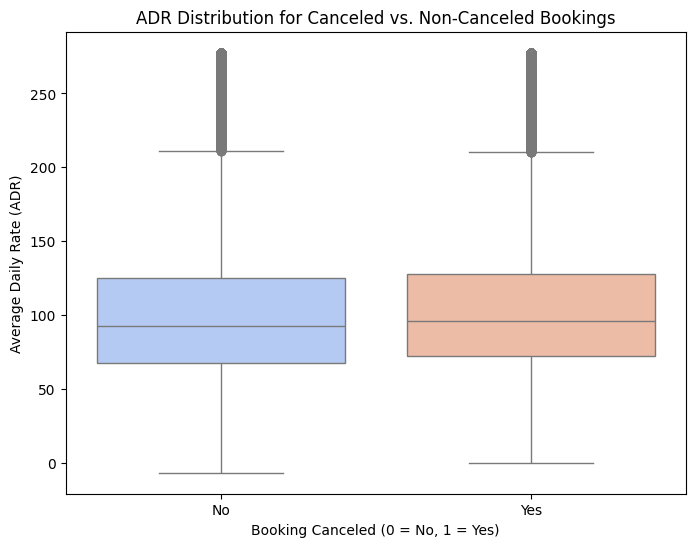

In [53]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='is_canceled', y='adr', hue='is_canceled', palette='coolwarm', legend=False)
plt.title('ADR Distribution for Canceled vs. Non-Canceled Bookings')
plt.xlabel('Booking Canceled (0 = No, 1 = Yes)')
plt.ylabel('Average Daily Rate (ADR)')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

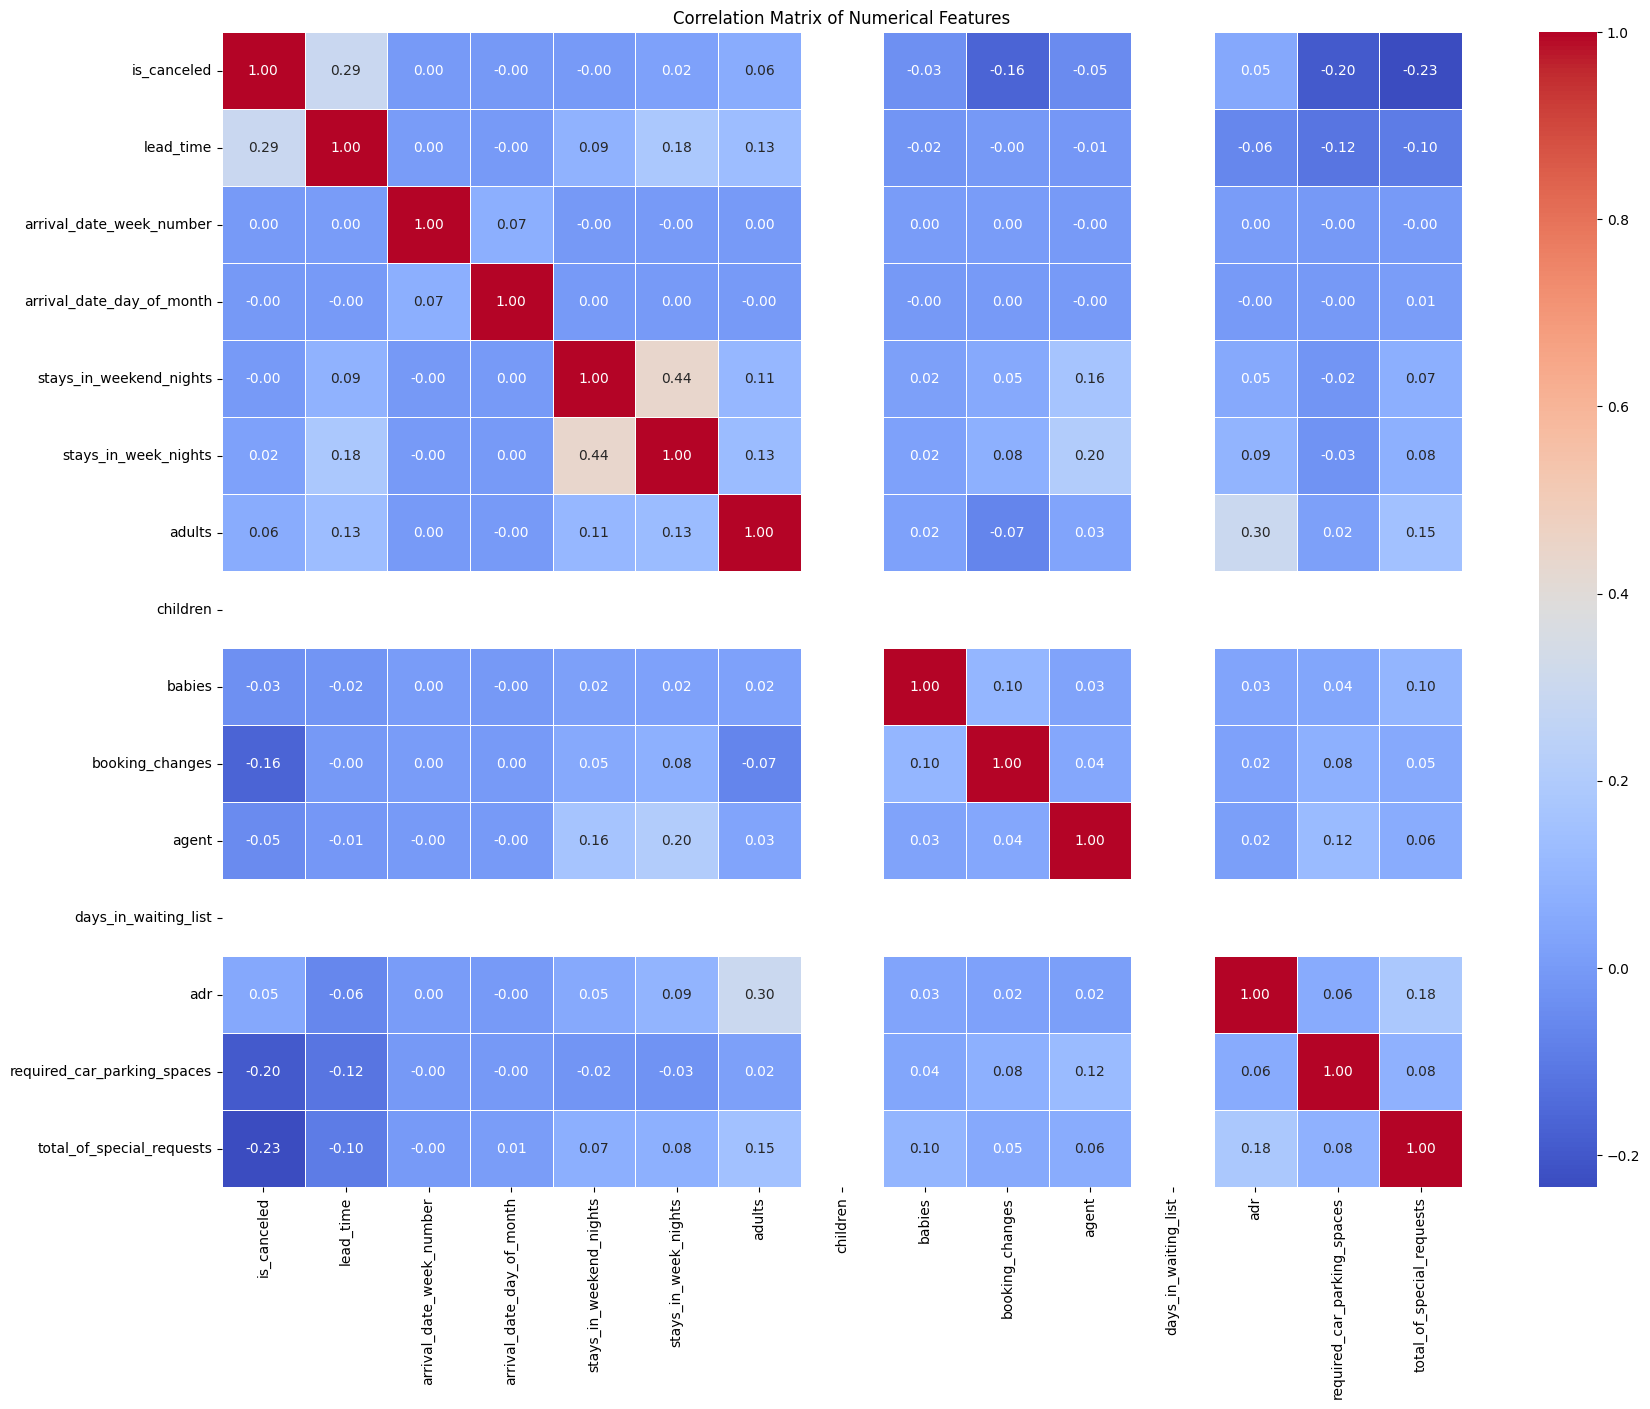

In [54]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

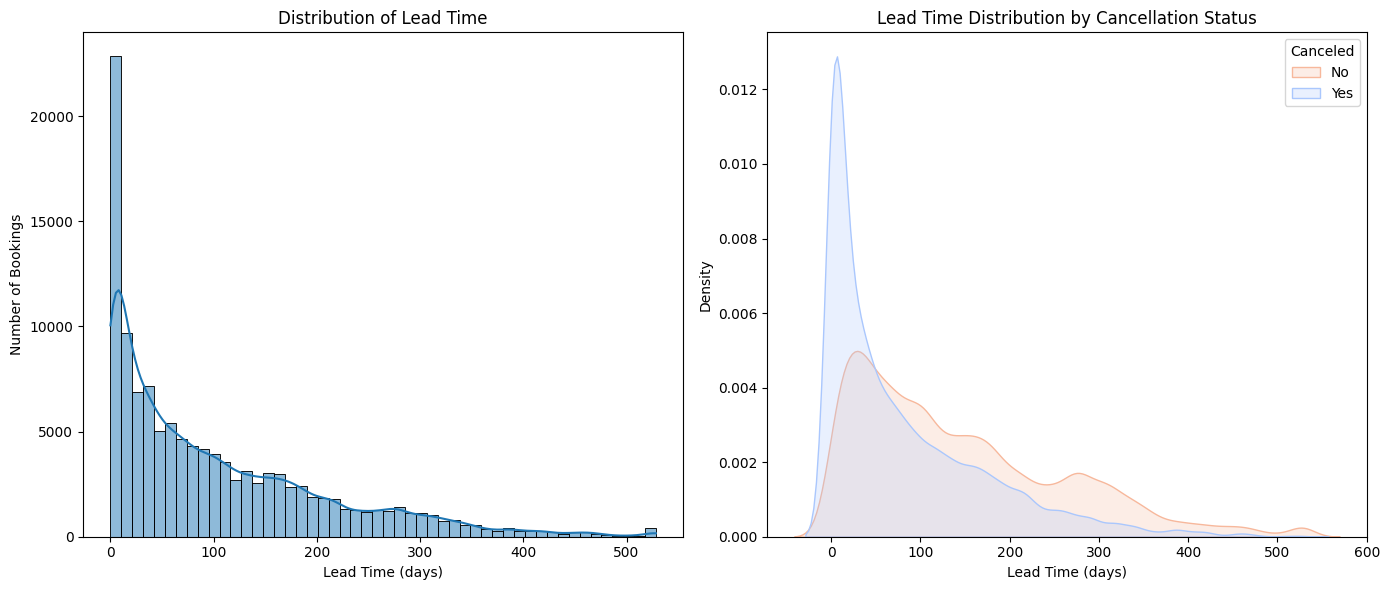

In [55]:
plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
sns.histplot(data=df, x='lead_time', bins=50, kde=True)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (days)')
plt.ylabel('Number of Bookings')

plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='lead_time', hue='is_canceled', fill=True, common_norm=False, palette='coolwarm')
plt.title('Lead Time Distribution by Cancellation Status')
plt.xlabel('Lead Time (days)')
plt.ylabel('Density')
plt.legend(title='Canceled', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

In [56]:
hotel_cols = [col for col in df.columns if col.startswith('hotel_')]

hotel_bookings = {}
hotel_cancellations = {}

for col in hotel_cols:
    hotel_name = col.replace('hotel_', '')
    total_bookings = df[col].sum()
    canceled_bookings = df[df['is_canceled'] == 1][col].sum()

    hotel_bookings[hotel_name] = total_bookings
    hotel_cancellations[hotel_name] = canceled_bookings

hotel_bookings_series = pd.Series(hotel_bookings)
hotel_cancellations_series = pd.Series(hotel_cancellations)
hotel_cancellation_rate = (hotel_cancellations_series / hotel_bookings_series * 100).fillna(0)

print("Total Bookings per Hotel Type:")
print(hotel_bookings_series)
print("\nCancellation Rate per Hotel Type (%):")
print(hotel_cancellation_rate)

Total Bookings per Hotel Type:
City Hotel - Bangalore       5205
City Hotel - Bhopal          5364
City Hotel - Chandigarh      5288
City Hotel - Chennai         5247
City Hotel - Delhi           5246
City Hotel - Goa             5295
City Hotel - Hyderabad       5337
City Hotel - Indore          5162
City Hotel - Jaipur          5342
City Hotel - Kochi           5162
City Hotel - Kolkata         5339
City Hotel - Lucknow         5286
City Hotel - Mumbai          5262
City Hotel - Pune            5339
Resort Hotel - Ahmedabad     2622
Resort Hotel - Bangalore     2687
Resort Hotel - Bhopal        2736
Resort Hotel - Chandigarh    2685
Resort Hotel - Chennai       2673
Resort Hotel - Delhi         2726
Resort Hotel - Goa           2676
Resort Hotel - Hyderabad     2641
Resort Hotel - Indore        2657
Resort Hotel - Jaipur        2693
Resort Hotel - Kochi         2723
Resort Hotel - Kolkata       2637
Resort Hotel - Lucknow       2579
Resort Hotel - Mumbai        2669
Resort Hotel - Pu

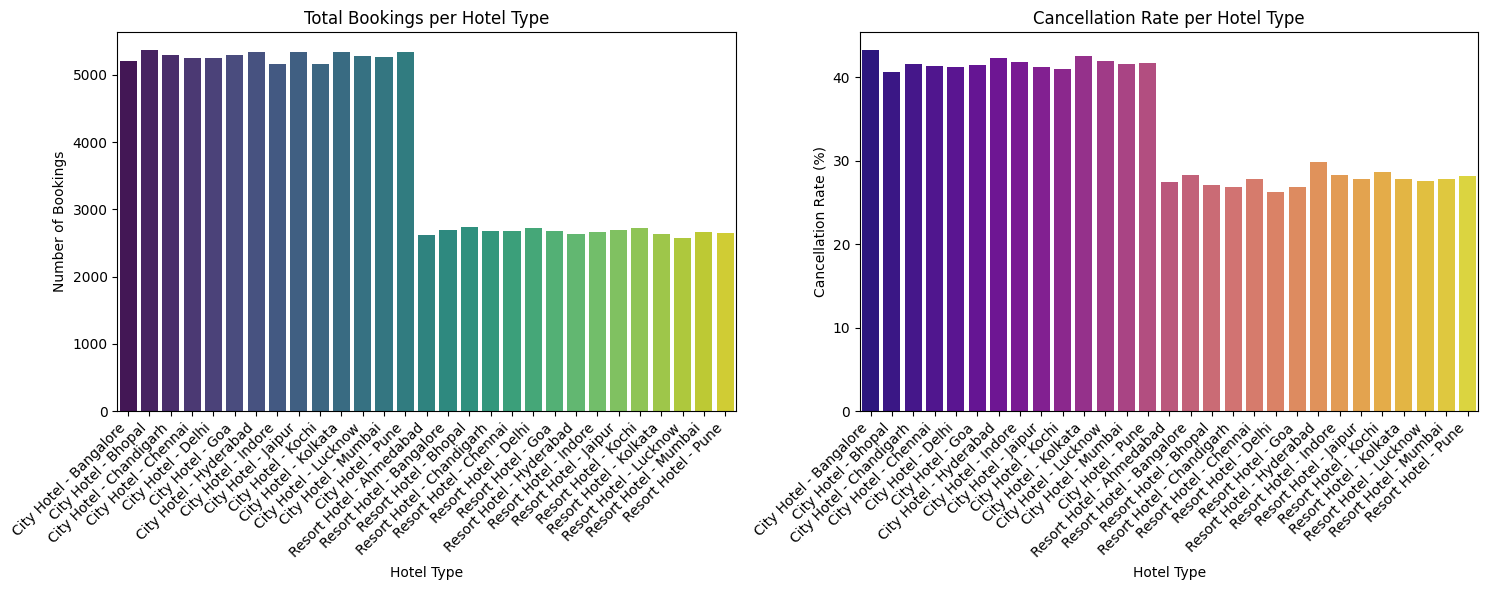

In [57]:
plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
sns.barplot(x=hotel_bookings_series.index, y=hotel_bookings_series.values, hue=hotel_bookings_series.index, palette='viridis', legend=False)
plt.title('Total Bookings per Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')


plt.subplot(1, 2, 2)
sns.barplot(x=hotel_cancellation_rate.index, y=hotel_cancellation_rate.values, hue=hotel_cancellation_rate.index, palette='plasma', legend=False)
plt.title('Cancellation Rate per Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [58]:
market_segment_cols = [col for col in df.columns if col.startswith('market_segment_')]

market_segment_bookings = {}
market_segment_cancellations = {}

for col in market_segment_cols:
    segment_name = col.replace('market_segment_', '')
    total_bookings = df[col].sum()
    canceled_bookings = df[df['is_canceled'] == 1][col].sum()

    market_segment_bookings[segment_name] = total_bookings
    market_segment_cancellations[segment_name] = canceled_bookings

market_segment_bookings_series = pd.Series(market_segment_bookings).sort_values(ascending=False)
market_segment_cancellations_series = pd.Series(market_segment_cancellations)
market_segment_cancellation_rate = (market_segment_cancellations_series / market_segment_bookings_series * 100).fillna(0).sort_values(ascending=False)

print("Total Bookings per Market Segment:")
print(market_segment_bookings_series)
print(
"Cancellation Rate per Market Segment (%):")
print(market_segment_cancellation_rate)



Total Bookings per Market Segment:
Online TA        56476
Offline TA/TO    24192
Groups           19779
Direct           12605
Corporate         5290
Complementary      743
Undefined            2
dtype: int64
Cancellation Rate per Market Segment (%):
Undefined        100.000000
Groups            61.009151
Online TA         36.721793
Offline TA/TO     34.275794
Corporate         18.695652
Direct            15.343118
Complementary     13.055182
dtype: float64


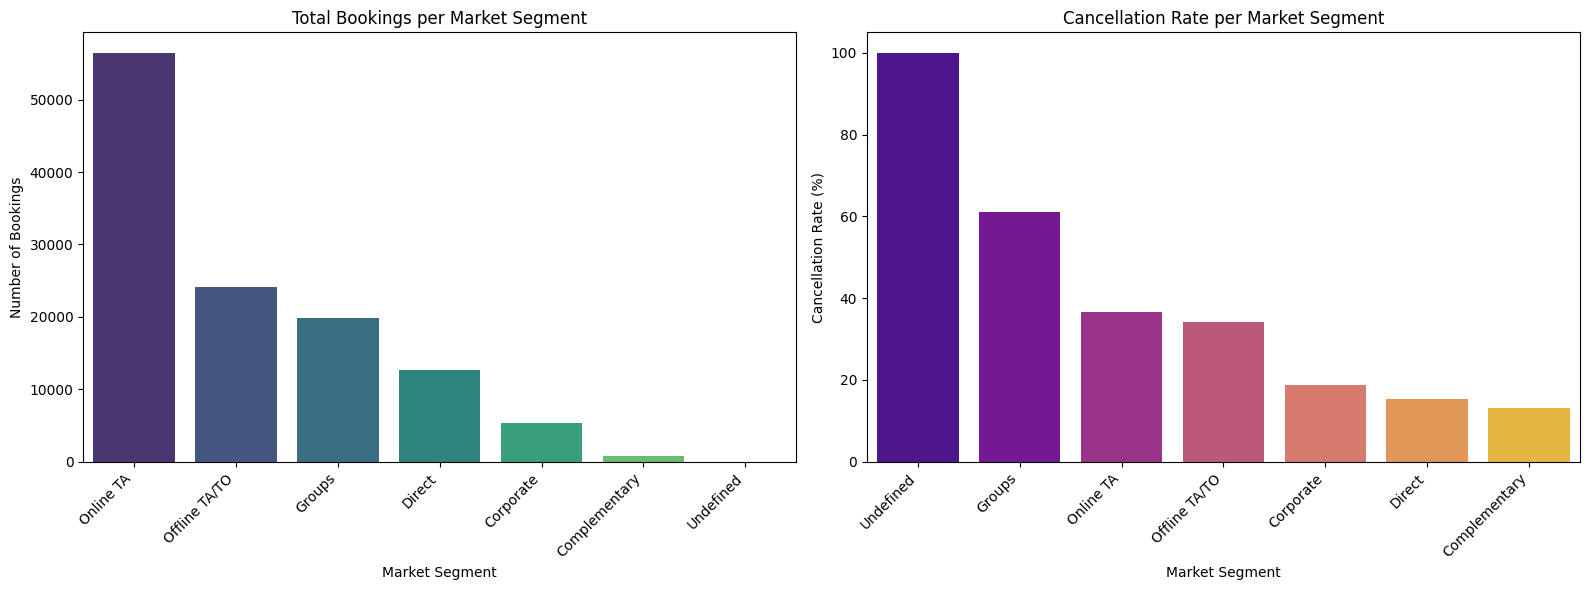

In [59]:
plt.figure(figsize=(16, 6))


plt.subplot(1, 2, 1)
sns.barplot(x=market_segment_bookings_series.index, y=market_segment_bookings_series.values, hue=market_segment_bookings_series.index, palette='viridis', legend=False)
plt.title('Total Bookings per Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')


plt.subplot(1, 2, 2)
sns.barplot(x=market_segment_cancellation_rate.index, y=market_segment_cancellation_rate.values, hue=market_segment_cancellation_rate.index, palette='plasma', legend=False)
plt.title('Cancellation Rate per Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [60]:
customer_type_cols = [col for col in df.columns if col.startswith('customer_type_')]

customer_type_bookings = {}
customer_type_cancellations = {}

for col in customer_type_cols:
    type_name = col.replace('customer_type_', '')
    total_bookings = df[col].sum()
    canceled_bookings = df[df['is_canceled'] == 1][col].sum()

    customer_type_bookings[type_name] = total_bookings
    customer_type_cancellations[type_name] = canceled_bookings

customer_type_bookings_series = pd.Series(customer_type_bookings).sort_values(ascending=False)
customer_type_cancellations_series = pd.Series(customer_type_cancellations)
customer_type_cancellation_rate = (customer_type_cancellations_series / customer_type_bookings_series * 100).fillna(0).sort_values(ascending=False)

print("Total Bookings per Customer Type:")
print(customer_type_bookings_series)
print("\nCancellation Rate per Customer Type (%):")
print(customer_type_cancellation_rate)



Total Bookings per Customer Type:
Transient          89569
Transient-Party    25105
Group                577
dtype: int64

Cancellation Rate per Customer Type (%):
Transient          40.720562
Transient-Party    25.417248
Group              10.225303
dtype: float64


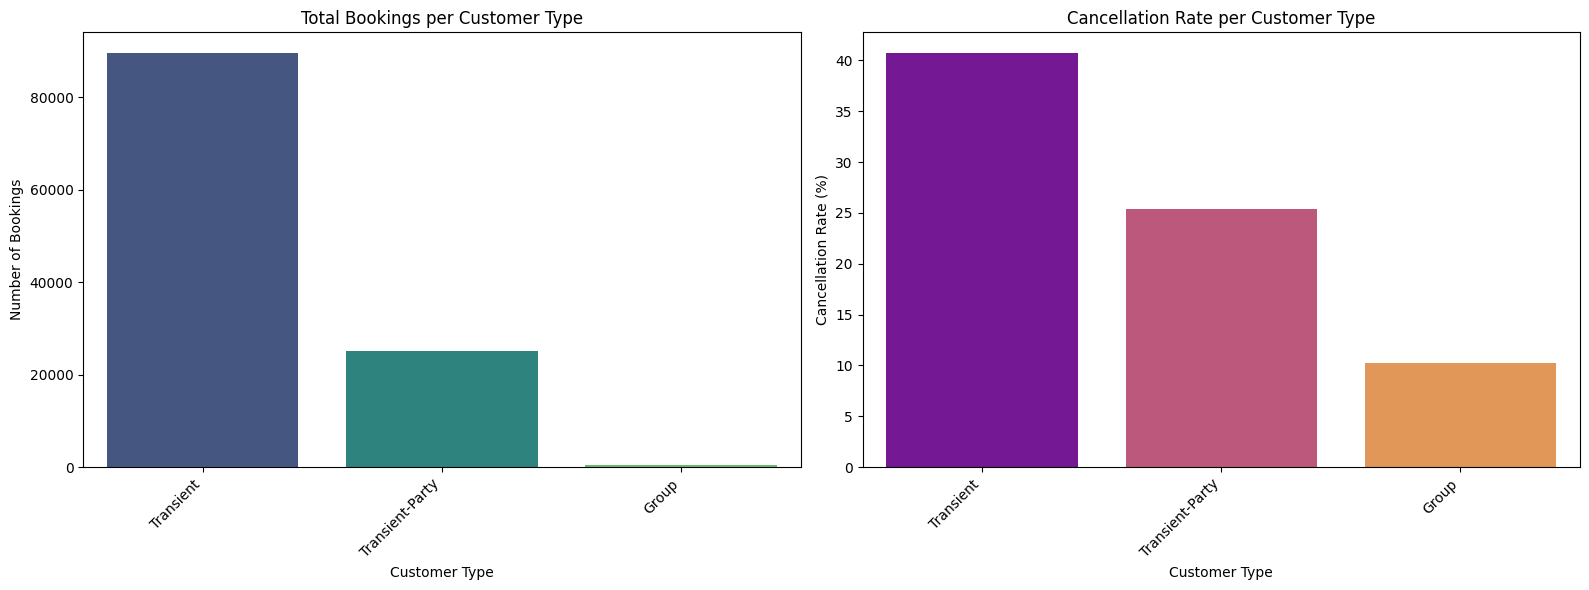

In [61]:
plt.figure(figsize=(16, 6))


plt.subplot(1, 2, 1)
sns.barplot(x=customer_type_bookings_series.index, y=customer_type_bookings_series.values, hue=customer_type_bookings_series.index, palette='viridis', legend=False)
plt.title('Total Bookings per Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')


plt.subplot(1, 2, 2)
sns.barplot(x=customer_type_cancellation_rate.index, y=customer_type_cancellation_rate.values, hue=customer_type_cancellation_rate.index, palette='plasma', legend=False)
plt.title('Cancellation Rate per Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# #C

In [62]:
df['is_canceled'].value_counts()

,count
is_canceled,
0,75152
1,44172


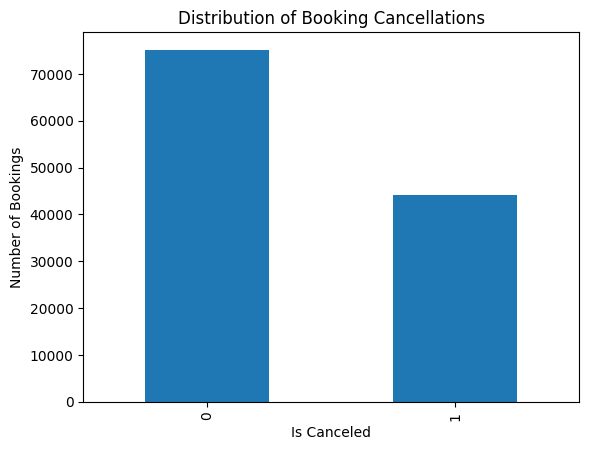

In [63]:
df['is_canceled'].value_counts().plot(kind='bar')
plt.xlabel('Is Canceled')
plt.ylabel('Number of Bookings')
plt.title('Distribution of Booking Cancellations')
plt.show()


In [64]:
(df['is_canceled'].value_counts(normalize=True) * 100)


,proportion
is_canceled,
0,62.981462
1,37.018538


In [65]:
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']


In [66]:
X_numeric = X.select_dtypes(include=np.number)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_numeric, y)


In [67]:
y_resampled.value_counts()

,count
is_canceled,
0,75152
1,75152


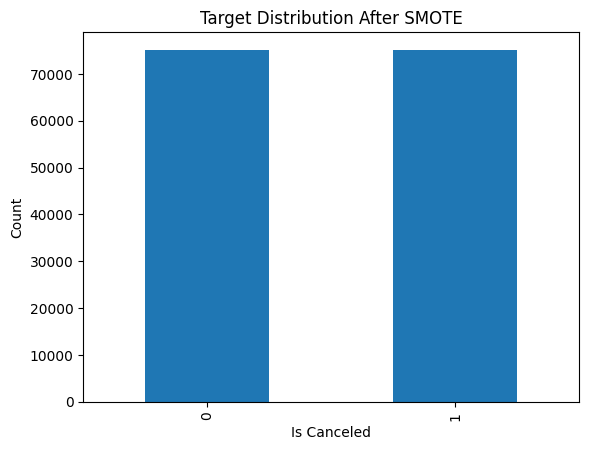

In [68]:
y_resampled.value_counts().plot(kind='bar')
plt.xlabel('Is Canceled')
plt.ylabel('Count')
plt.title('Target Distribution After SMOTE')
plt.show()


# #d

In [69]:

df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']


In [70]:
df['family_size'] = df['adults'] + df['children'] + df['babies']


In [71]:
df['is_family'] = df['family_size'].apply(lambda x: 1 if x > 1 else 0)


# #E

In [73]:
def fitness_function(individual, x, y):
  selected_features = x[:, individual == 1]
  if selected_features.shape[1] == 0:
    return 0
  model = RandomForestClassifier(random_state=42)
  score = cross_val_score(model, selected_features, y, cv=2).mean()

  return score

In [74]:
X_ga = np.asarray(X)

y_ga = np.asarray(y)
def genetic_algorithm(X_ga, y_ga, population_size=10, generations=8, mutation_rate=0.1):

    n_features = X_ga.shape[1]
    population = np.random.randint(0, 2, size=(population_size, n_features))

    for _ in range(generations):

        fitness_scores = np.array([
            fitness_function(ind, X_ga, y_ga) for ind in population
        ])

        selected = population[np.argsort(fitness_scores)[-population_size // 2:]]

        offspring = []
        while len(offspring) < population_size:
            p1, p2 = random.sample(list(selected), 2)
            cp = random.randint(1, n_features - 1)
            child = np.concatenate((p1[:cp], p2[cp:]))
            offspring.append(child)

        offspring = np.array(offspring)

        for ind in offspring:
            if random.random() < mutation_rate:
                m = random.randint(0, n_features - 1)
                ind[m] = 1 - ind[m]

        population = offspring

    final_fitness = np.array([
        fitness_function(ind, X_ga, y_ga) for ind in population
    ])

    return population[final_fitness.argmax()]


In [ ]:
best_features = genetic_algorithm(X_ga, y_ga)

mask = best_features.astype(bool)

X_selected = X.iloc[:, mask]

print("Selected features:", np.sum(mask))

In [ ]:
model = RandomForestClassifier(random_state=42)
score_before = cross_val_score(model,X,y, cv=2).mean()
score_after = cross_val_score(model,X_selected,y, cv=2).mean()
print("Accuracy before GA:", score_before)
print("Accurancy after GA:",score_after)

# #Part F

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
k_values = [3, 5, 7, 9, 11]
best_k = None
best_val_acc = 0

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    val_pred = knn.predict(X_val_scaled)
    acc = accuracy_score(y_val, val_pred)

    if acc > best_val_acc:
        best_val_acc = acc
        best_k = k

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
knn_test_pred = knn_final.predict(X_test_scaled)

In [ ]:
depths = [None, 5, 10, 20, 30]
best_depth = None
best_val_acc = 0

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)

    val_pred = dt.predict(X_val)
    acc = accuracy_score(y_val, val_pred)

    if acc > best_val_acc:
        best_val_acc = acc
        best_depth = d

dt_final = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_final.fit(X_train, y_train)
dt_test_pred = dt_final.predict(X_test)

In [ ]:
hidden_layers = [(50,), (100,), (50,50)]
learning_rates = [0.001, 0.01]

best_params = None
best_val_acc = 0

for h in hidden_layers:
    for lr in learning_rates:
        mlp = MLPClassifier(
            hidden_layer_sizes=h,
            learning_rate_init=lr,
            max_iter=500,
            random_state=42
        )
        mlp.fit(X_train_scaled, y_train)

        val_pred = mlp.predict(X_val_scaled)
        acc = accuracy_score(y_val, val_pred)

        if acc > best_val_acc:
            best_val_acc = acc
            best_params = (h, lr)

mlp_final = MLPClassifier(
    hidden_layer_sizes=best_params[0],
    learning_rate_init=best_params[1],
    max_iter=500,
    random_state=42
)

mlp_final.fit(X_train_scaled, y_train)
mlp_test_pred = mlp_final.predict(X_test_scaled)

# #G

In [ ]:
def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("F1-score :", f1_score(y_true, y_pred, average='weighted'))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

evaluate("KNN", y_test, knn_test_pred)
evaluate("Decision Tree", y_test, dt_test_pred)
evaluate("MLP", y_test, mlp_test_pred)

In [ ]:
cm_dt = confusion_matrix(y_test, dt_test_pred)
cm_dt_percent = cm_dt.astype('float') / cm_dt.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_percent, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Decision Tree Model (Percentages)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
cm_knn = confusion_matrix(y_test, knn_test_pred)
cm_knn_percent = cm_knn.astype('float') / cm_knn.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn_percent, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for KNN Model (Percentages)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
cm_mlp = confusion_matrix(y_test, mlp_test_pred)
cm_mlp_percent = cm_mlp.astype('float') / cm_mlp.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp_percent, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for MLP Model (Percentages)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
scores = {}

for name, pred in [
    ("KNN", knn_test_pred),
    ("Decision Tree", dt_test_pred),
    ("MLP", mlp_test_pred)
]:
    f1 = f1_score(y_test, pred, average='weighted')
    scores[name] = f1

best_model = max(scores, key=scores.get)

print("\nBest model selected based on weighted F1-score:")
print(best_model, "with F1 =", scores[best_model])